# Centroid Tracking with fixed k

- Can fix k to make things easy 
- Could take intersection although i dont think necessary

Can calculate distance between centroids or track how the entire clustering shifts. Can use OT the Wassserstein/ Earth Mover distance.

In [1]:
# Main packages 
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Clustering packages
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score,adjusted_rand_score

# Parallel processing packages
from joblib import Parallel, delayed

In [2]:
# Load data
df = pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz",has_header=False,separator=",",
                 new_columns= ['time','src_user','dest_user','src_comp','dest_comp',
                               'auth_type','logon_type','auth_orientation','outcome'])

In [3]:
# Keep only human users
df = df.filter(pl.col("src_user").str.starts_with("U"))

## Functions & Global info

In [4]:
# Time conversions
seconds_in_day = 60 * 60 * 24

# Time aggregation
agg_hour_level = 3

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

# Silhouette sample size 
sample_size = 1000

In [5]:
# FUNCTION - build features dataframe
def build_features(df,agg_hour_level):

    agg_seconds = agg_hour_level * 60 * 60

    return (
        df.with_columns(
            bucket = pl.col('time') // agg_seconds,
            theta = ((pl.col('time') % seconds_in_day)/ seconds_in_day) * 2 * np.pi,
            is_failure = (pl.col('outcome') == 'Fail').cast(pl.Int8),
        )
        .group_by(['src_user','bucket'])
        .agg(
            n_events = pl.len(),
            failure_ratio = pl.col('is_failure').mean(),
            n_distinct_dest = pl.col('dest_comp').n_unique(),
            n_distinct_src = pl.col('src_comp').n_unique(),
            c_bar = pl.col('theta').cos().mean(),
            s_bar = pl.col('theta').sin().mean(),
        )
        .with_columns(
             log_n_events=pl.col("n_events").log1p(),
             log_n_distinct_dest=pl.col("n_distinct_dest").log1p(),
             log_n_distinct_src=pl.col("n_distinct_src").log1p(),
        )
        .collect()
    )

In [6]:
# Relevant feauture columns
feature_cols = [
    "log_n_events",
    "failure_ratio",
    "log_n_distinct_dest",
    "log_n_distinct_src",
    "c_bar",
    "s_bar",
]

In [7]:
# FUNCTION - process features for clustering 
def cluster_preprocess(features_df,feature_cols,week):

    lb = (week - 1) * buckets_per_week
    ub = lb + buckets_per_week - 1

    features_week = features_df.filter(pl.col('bucket').is_between(lb,ub))

    X = features_week.select(feature_cols).to_numpy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return features_week, X_scaled

In [8]:
# FUNCTION - kmeans 
def fit_kmeans(k, Y, sample_size):
    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(Y)
    
    sil = silhouette_score(Y, labels, sample_size=sample_size, random_state=123)
    ch  = calinski_harabasz_score(Y, labels)   
    db  = davies_bouldin_score(Y, labels)    
    
    return k, sil,ch,db

In [9]:
# Create features dataframe
features_df = build_features(df,agg_hour_level)

## Clustering

In [10]:
# Cluster for each week
n_weeks = 8
k = 3
weekly_centroids = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled = cluster_preprocess(features_df, feature_cols, week=week)

    km = KMeans(n_clusters= k, random_state=123, n_init=10) 
    labels = km.fit_predict(X_scaled)   

    weekly_centroids[week] = km.cluster_centers_

## Centroid Tracking

In [11]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

centroid_distances = []  

for week in range(1, n_weeks):
    C1 = weekly_centroids[week]      
    C2 = weekly_centroids[week + 1]  

    cost = cdist(C1, C2, metric='euclidean')  

    row_ind, col_ind = linear_sum_assignment(cost)

    matched_dist = cost[row_ind, col_ind].mean()
    centroid_distances.append(matched_dist)

    print(f"Week {week} → {week+1}: matched distances {cost[row_ind, col_ind].round(3)}, mean = {matched_dist:.3f}")

Week 1 → 2: matched distances [0.063 0.073 0.184], mean = 0.107
Week 2 → 3: matched distances [0.045 0.035 0.224], mean = 0.101
Week 3 → 4: matched distances [0.036 0.039 0.175], mean = 0.083
Week 4 → 5: matched distances [0.025 0.029 0.17 ], mean = 0.075
Week 5 → 6: matched distances [0.338 0.911 2.357], mean = 1.202
Week 6 → 7: matched distances [0.091 0.256 0.214], mean = 0.187
Week 7 → 8: matched distances [0.101 0.151 0.09 ], mean = 0.114


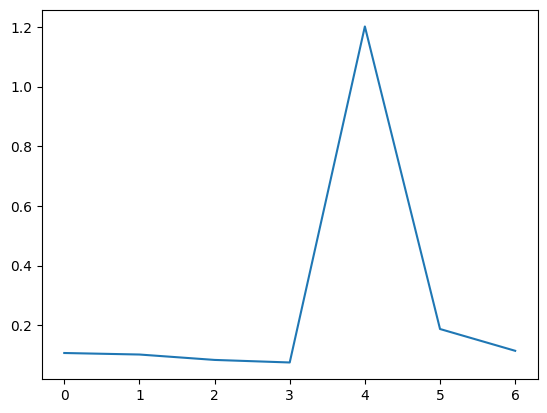

In [14]:
plt.plot(centroid_distances)

ARI is tracking cluster membership 
but here we are measuring how the centroids are moving, but there is something that its just the center and that different clusters can be close together say admin users and non-admin could be closest in space across windows

I could do ARI with fixed k and then have this centroid tracking with fixed k to be able to compare easier

I could do the variable k using the silhouette score etc, then compare ARI and centroid (using OT)